<a href="https://colab.research.google.com/github/Bhagya-Navodyani/DL_Lab_6/blob/main/lab_7_AE_CNN_Image_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [32]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()


In [33]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.



In [34]:
x_train = x_train[..., tf.newaxis] #adds a additional axis (60000,28,28) --> (60000,28,28,1)
x_test = x_test[..., tf.newaxis]
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [35]:
tf.random.normal(shape=x_train.shape)

<tf.Tensor: shape=(60000, 28, 28, 1), dtype=float32, numpy=
array([[[[-1.50724399e+00],
         [-2.73995250e-01],
         [ 1.09376454e+00],
         ...,
         [ 7.74279088e-02],
         [ 5.18003032e-02],
         [ 1.65494716e+00]],

        [[ 2.31722713e+00],
         [ 5.11524737e-01],
         [-9.79678929e-01],
         ...,
         [ 1.06132515e-01],
         [ 3.75265539e-01],
         [ 2.12773904e-02]],

        [[-2.14815688e+00],
         [-9.22634244e-01],
         [-4.32759374e-01],
         ...,
         [-3.62883389e-01],
         [-1.10475373e+00],
         [ 3.37164760e-01]],

        ...,

        [[ 3.16604197e-01],
         [-7.96963215e-01],
         [-8.41717958e-01],
         ...,
         [-1.30066597e+00],
         [-1.35297203e+00],
         [ 1.12734473e+00]],

        [[ 6.66286290e-01],
         [-1.18237150e+00],
         [-3.15333724e-01],
         ...,
         [ 6.13913275e-02],
         [-4.65896279e-01],
         [-3.28461170e-01]],

      

In [36]:
# noise_factor = 0.3
# noise_factor = 0.4
noise_factor = 0.2
x_train_noisy = x_train  +  noise_factor * tf.random.normal(shape=x_train.shape)
# noise factor multiplication result in increased spread in noise distribution
# result in 0.2^2 increase of variance, mean doesn't chnage (mean = 0)
x_test_noisy = x_test  +  noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

In [37]:
x_test_noisy.shape

TensorShape([10000, 28, 28, 1])

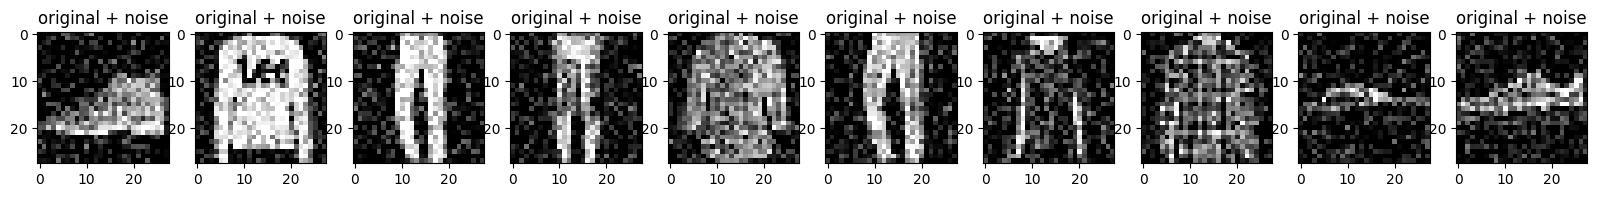

In [38]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

In [39]:
class Denoise(Model):
    def __init__(self):
        super(Denoise, self).__init__()
        self.encoder = tf.keras.Sequential([
          layers.Input(shape=(28, 28, 1)),
          layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
          layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)])

        self.decoder = tf.keras.Sequential([
          layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
          layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
          layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [40]:
autoencoder = Denoise()

In [41]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [42]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=30,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - loss: 0.0195 - val_loss: 0.0115
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - loss: 0.0106 - val_loss: 0.0101
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - loss: 0.0083 - val_loss: 0.0082
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - loss: 0.0081 - val_loss: 0.0081
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 12

In [49]:
autoencoder.encoder.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
autoencoder.decoder.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose_2              │ (32, 14, 14, 8)        │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (32, 28, 28, 16)       │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 28, 28, 1)        │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897 (7.41 KB)

 Trainable params: 1,897 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
encoded_imgs = autoencoder.encoder(x_test_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

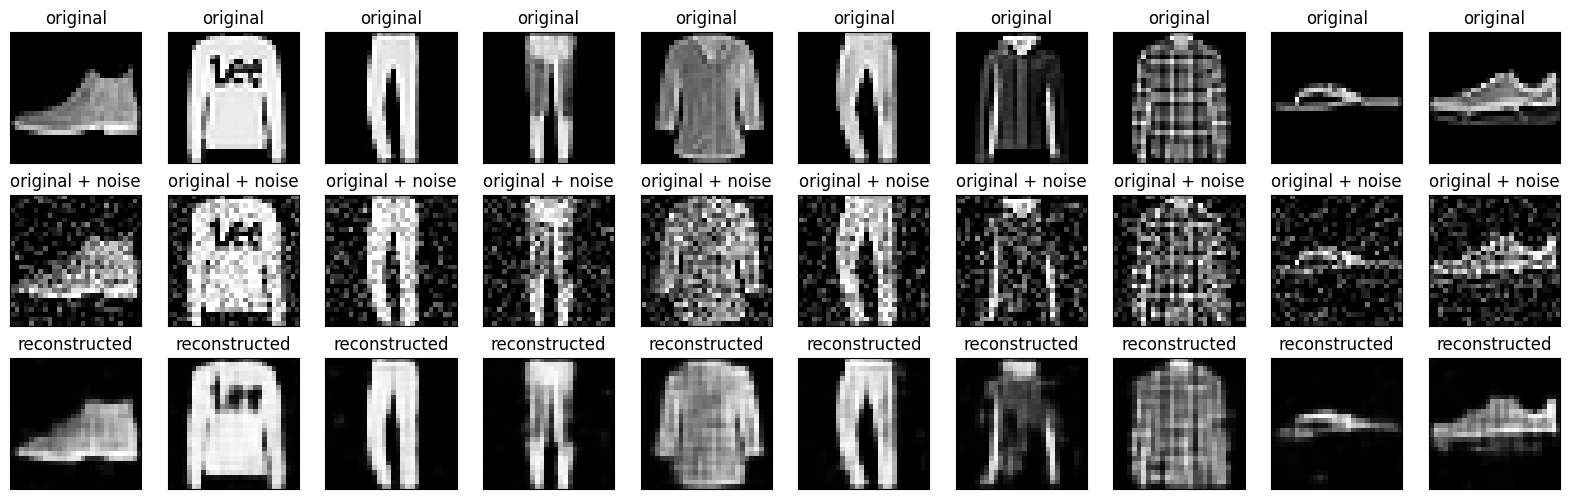

In [46]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # display original
    ax = plt.subplot(3, n, i + 1)
    plt.title("original")
    plt.imshow(tf.squeeze(x_test[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display original + noise
    ax = plt.subplot(3, n, i + n + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    bx = plt.subplot(3, n, i + 2*n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()

In [47]:
reconstructed_test = autoencoder.predict(x_test_noisy)

mse = tf.keras.losses.MeanSquaredError()
test_mse = mse(x_test, reconstructed_test)

print("Test Mean Squared Error:", test_mse.numpy())

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Test Mean Squared Error: 0.0070925714


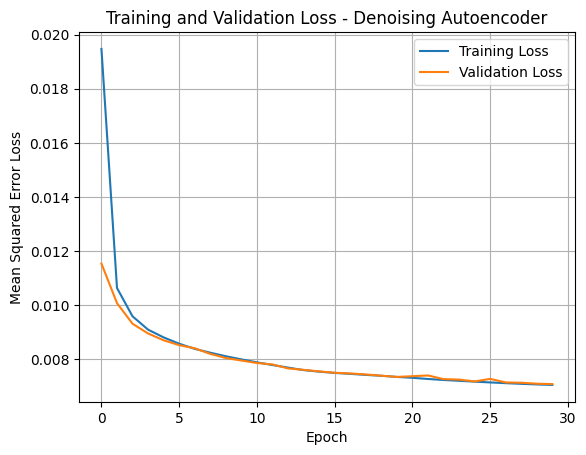

In [48]:
plt.plot(autoencoder.history.history['loss'], label='Training Loss')
plt.plot(autoencoder.history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training and Validation Loss - Denoising Autoencoder')
plt.legend()
plt.grid(True)

plt.show()